# Cluster Dataset (4x SIS)

In this demo we show the generation of a dataset for machine
learning sporting two SIE lenses.

::: {warning} 
This demo uses a feature from CosmoSim v3.2, taking the Critical Curve
into account when placing the sources.  This will not work in v3.1.
:::

::: {warning}
Work in progress
:::

## Preparation

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import json
from CosmoSim.datagen import SimImage
import CosmoSim.Image as csimg
import CosmoSim.dataset as csd
from CosmoSim import Parameters

The distribution of the dataset is configured as follows.

In [2]:
cfg = csd.readtoml( "cluster4-dataset.toml" )
display( json.dumps( cfg ) )

'{"simulator": {"model": "Raytrace", "size": 15000, "nterms": 4, "imagesize": 512, "cropsize": 256, "centred": true}, "dataset": {"directory": "images"}, "lens": {"mode": "SIS", "einstein-min": 3, "einstein-max": 75}, "cluster": {"count": 4, "maxrelativelocation": 1.2}, "source": {"mode": "SersicSphere", "n_sersic-min": 1, "n_sersic-max": 5, "luminosity-min": 20, "luminosity-max": 80, "luminosity-lambda": 2.0, "sigma-min": 5, "sigma-max": 50, "position": "critical"}, "position": {"phi-min": 0, "phi-max": 360, "r-relativemax": 1.2}}'

Each constituent lens is placed in a random direction from the origin,
at a random distance upper bounded as $c\theta_E$ where $\theta_E$ is
the Einstein radius and $c$ is the constant given as `cluster.maxrelativelocation`.

We can draw a random object as before.

## A sample

Let us make a random sample for review.
Firstly, we make a convenience function to run one simulation and
retrieve the image.

In [3]:
def mkimg(ob):
      p0 = Parameters( )
      p0.setRow( ob )
      sim = SimImage( p0, verbose=0 )
      return sim.getImage()

Using this function, we can make a list of simulations, and plot the
results.

[getline] idx=0
[CosmoSim/py] setCluster(SIS/-8.94930400329674/-1.2628950102337924/11.629489961895878;SIS/-51.09718900750488/22.005396291039492/71.9196328920717;SIS/1.7261018508143968/-6.450710148645546/11.032284585296438;SIS/-2.7026409588290163/2.653148544256498/8.83787908530558)


[getline] idx=0
[CosmoSim/py] setCluster(SIS/-5.329996055691619/-3.6077006144921846/38.2532783080905;SIS/-8.884194512063846/29.158591959310396/25.85457540266612;SIS/4.2218921047960505/-12.493368299232515/17.41249032756505;SIS/20.152298488833196/-35.17306347661257/44.47172096877422)


[getline] idx=0
[CosmoSim/py] setCluster(SIS/-5.1382823559072/1.115026924336657/26.971602414839577;SIS/-13.518095551606828/35.37914593056842/49.82495470554021;SIS/17.841087472450635/23.04915988162793/29.31588550593046;SIS/0.003606930561308078/5.185274255444075/15.845605044571926)


[getline] idx=0
[CosmoSim/py] setCluster(SIS/2.816202453340989/0.68450988959695/32.96860853480009;SIS/-24.151458761115972/2.707486291157195/58.321687560752004;SIS/12.97270457441231/-66.86219738351363/64.83631379929977;SIS/-30.05006679991627/72.60600795069355/66.08003984191171)


[getline] idx=0
[CosmoSim/py] setCluster(SIS/36.113405113222804/24.557739519247534/66.85414171668168;SIS/-2.3732592610438865/3.4618568735454307/51.53125397437316;SIS/-14.269633246266835/-32.240447568930605/41.08934691977268;SIS/-4.0787477171571656/6.350158167046547/10.40034344494114)


[getline] idx=0
[CosmoSim/py] setCluster(SIS/-3.819282747974558/0.1935944126019628/26.555111627888177;SIS/-0.8184592525957993/-1.5393987990644744/7.14407503720143;SIS/2.9235753042148636/-24.395776570730263/21.412598173518106;SIS/14.509111662125367/9.687756236341103/15.442540805359823)


[getline] idx=0
[CosmoSim/py] setCluster(SIS/2.2637368514804628/43.21566215655706/37.36366329324789;SIS/-53.44200945149047/-5.044512431139081/73.1270002359709;SIS/-6.2016078648082535/-26.62329074436847/30.36074933674837;SIS/-10.975547614588717/14.008515949438653/74.26904159180363)


[getline] idx=0
[CosmoSim/py] setCluster(SIS/50.88605372002671/11.337789705391526/54.041306653235004;SIS/-0.4109613491512435/3.737071916442301/69.03880787553648;SIS/26.427143755035452/32.74653572919505/35.385520930774746;SIS/17.04300514694496/-10.228905636297876/19.71383030433687)


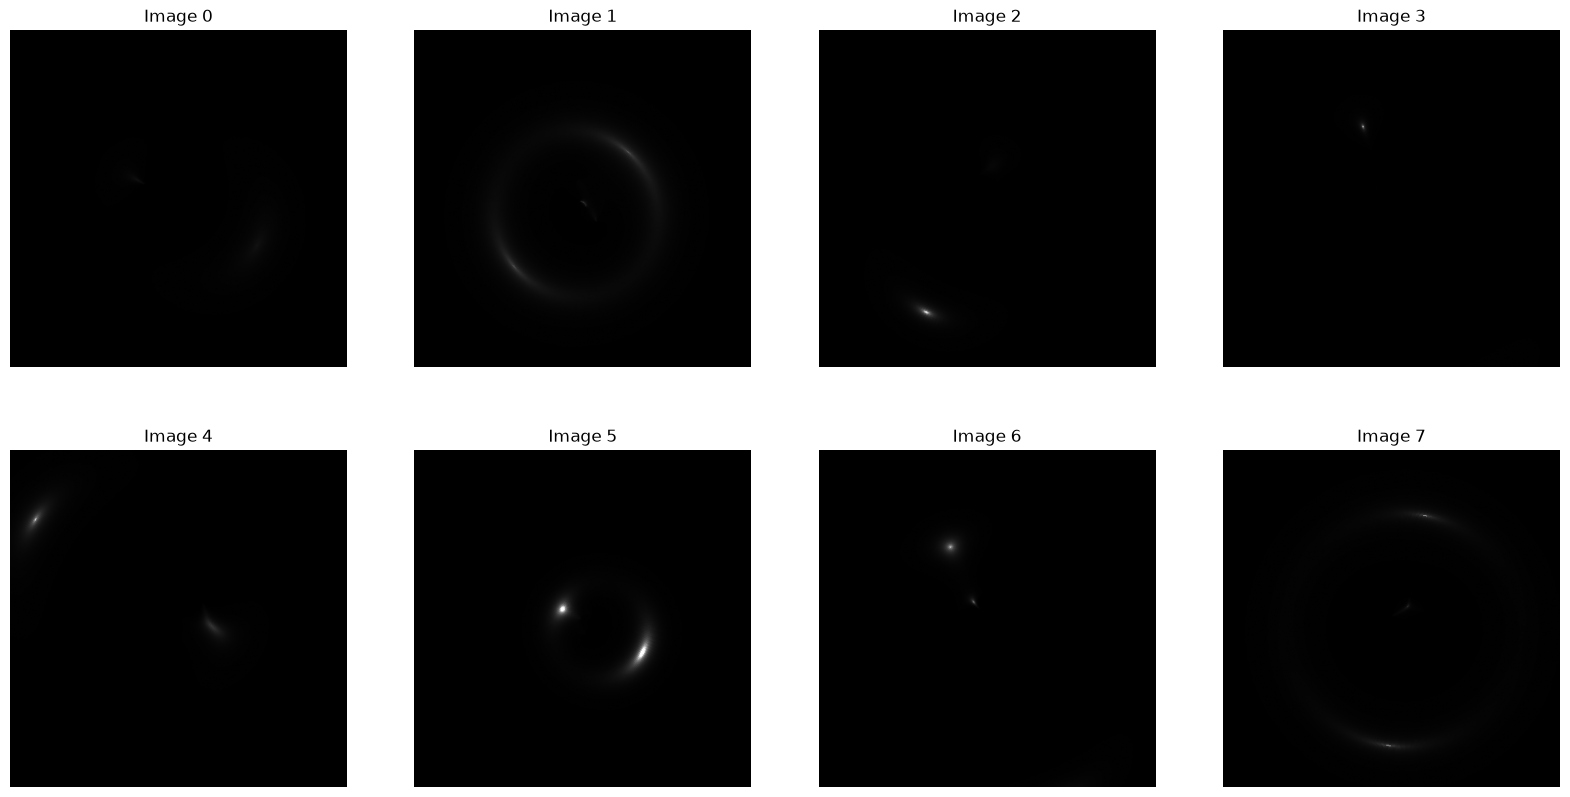

In [4]:
obs = [ csd.getline( cfg ) for _ in range(8) ]
ims = [ mkimg(ob) for ob in obs ]
ts = [ f"Image {i}" for i in range(8) ]
csimg.showImages( ims, size=(2,4), titles=ts )

If we take a particular  interest in one particular image, say no 1, we can easily inspect its parameters.

In [5]:
print( obs[1] )

index                                                         0
filename                                       image-000000.png
model                                                  Raytrace
cluster       SIS/-5.329996055691619/-3.6077006144921846/38....
source                                             SersicSphere
R                                                     24.684489
phi                                                  244.218545
sigma                                                 33.905305
sigma2                                                12.580921
theta                                                117.850496
n_sersic                                               1.787723
luminosity                                            61.012466
x                                                    -10.736264
y                                                    -22.227385
dtype: object


The cluser specification does not show in the row view, but we can single that one out to see properly.

In [6]:
print( obs[1]["cluster"] )

SIS/-5.329996055691619/-3.6077006144921846/38.2532783080905;SIS/-8.884194512063846/29.158591959310396/25.85457540266612;SIS/4.2218921047960505/-12.493368299232515/17.41249032756505;SIS/20.152298488833196/-35.17306347661257/44.47172096877422


## Closure

**TODO**